# ViToxic-Analyzer — Stage 1: Data Engineering & EDA

**Câu hỏi nghiên cứu:** Dữ liệu có mất cân bằng, trùng lặp hoặc xung đột nhãn đến mức nào? Chuẩn hóa thế nào để giữ tín hiệu hữu ích cho phân loại?

Notebook tái tạo kết quả từ CSV thật. Chỉ khám phá nội dung **train**; validation/test chỉ được audit cấu trúc, phân bố nhãn và overlap. Chưa huấn luyện model. Một số biểu đồ chứa ngôn ngữ xúc phạm từ dữ liệu nghiên cứu.

Nguồn: [ViHSD](https://github.com/sonlam1102/vihsd), [PhoBERT](https://github.com/VinAIResearch/PhoBERT).

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src').exists(), 'Mở notebook từ project hoặc notebooks/'
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import display, Image, Markdown
from src.stage1 import run
from src.data_loader import LABELS
from src.preprocessing import preprocess_text, PreprocessingConfig
report = run(ROOT / 'data', ROOT / 'reports/stage1', ROOT / 'data/processed')
train = pd.read_csv(ROOT / 'data/processed/train.csv', keep_default_na=False)
print('Đã tái tạo audit, processed data và figures.')

Đã tái tạo audit, processed data và figures.


## 1. Schema, missing values và phân bố nhãn

Loader kiểm tra cột và miền nhãn. Ô trống được đếm riêng; chuỗi literal `NA` không bị chuyển thành missing. `duplicate_excess` là số dòng dư sau lần xuất hiện đầu tiên, không phải số nhóm.

,rows,CLEAN,OFFENSIVE,HATE,empty_raw,empty_clean,raw_duplicate_excess,normalized_duplicate_excess,conflicting_groups
split,,,,,,,,,
train,24048,19886,1606,2556,2,2,1490,1535,132
validation,2672,2190,212,270,0,0,22,22,1
test,6680,5548,444,688,0,0,104,107,6


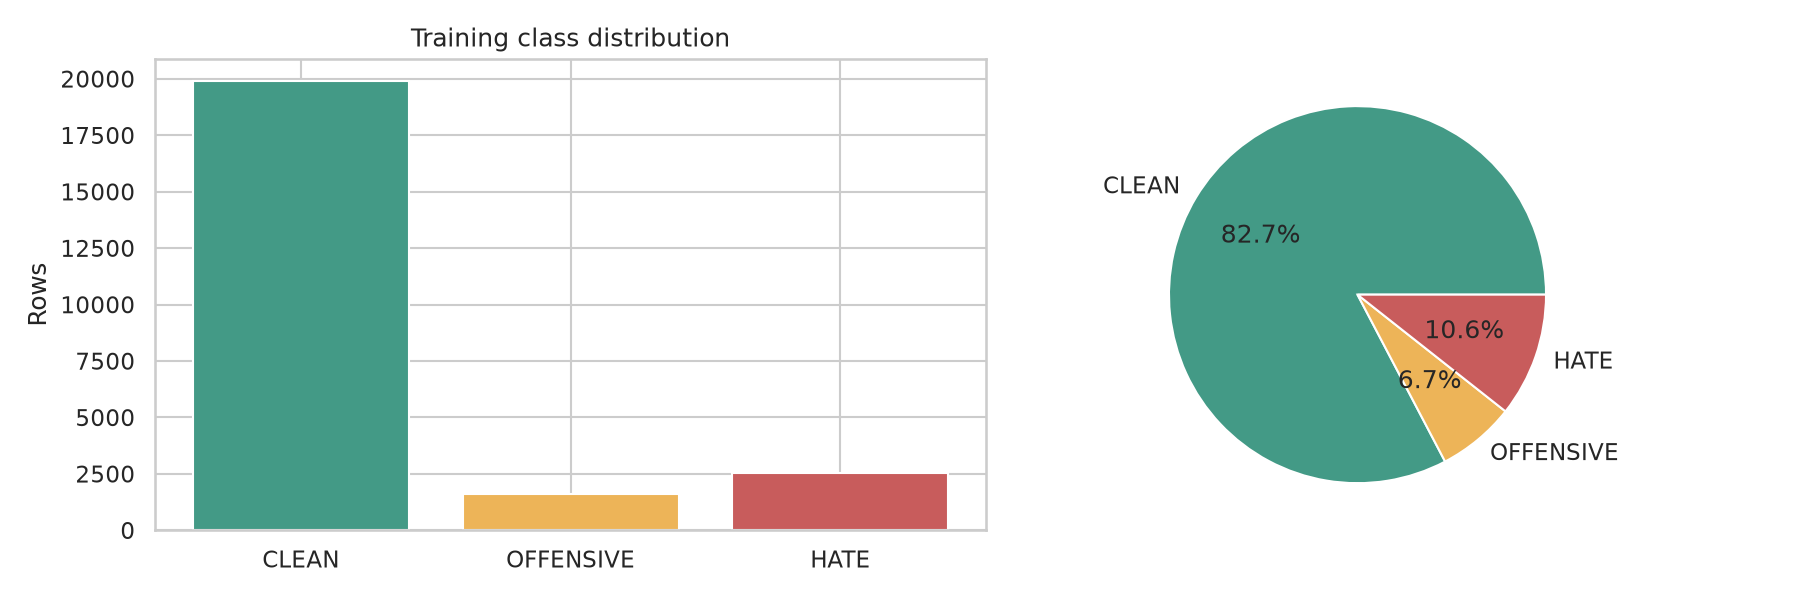

In [2]:
rows = []
for split, values in report['splits'].items():
    rows.append({'split': split, 'rows': values['rows'],
                 **{LABELS[int(k)]: v for k, v in values['label_counts'].items()},
                 'empty_raw': values['empty_raw'], 'empty_clean': values['empty_clean'],
                 'raw_duplicate_excess': values['raw_duplicate_excess'],
                 'normalized_duplicate_excess': values['normalized_duplicate_excess'],
                 'conflicting_groups': values['conflicting_normalized_groups']})
display(pd.DataFrame(rows).set_index('split'))
display(Image(filename=str(ROOT / 'reports/stage1/figures/label_distribution.png')))

## 2. Độ dài văn bản

Đếm đơn vị phân cách bởi khoảng trắng, **không phải số từ tiếng Việt hoặc PhoBERT subword**. Histogram dùng log ở trục số lượng; box plot dùng symlog để vẫn thấy đuôi dài. Không chốt max_length=256 chỉ từ biểu đồ này.

,count,mean,std,min,50%,90%,95%,99%,max
label_id,,,,,,,,,
0,19886.0,10.481997,20.573147,0.0,8.0,19.0,27.0,53.00,1701.0
1,1606.0,10.738481,10.679650,0.0,8.0,22.0,29.0,57.95,97.0
2,2556.0,19.969484,17.467371,1.0,14.0,43.0,59.0,79.45,162.0


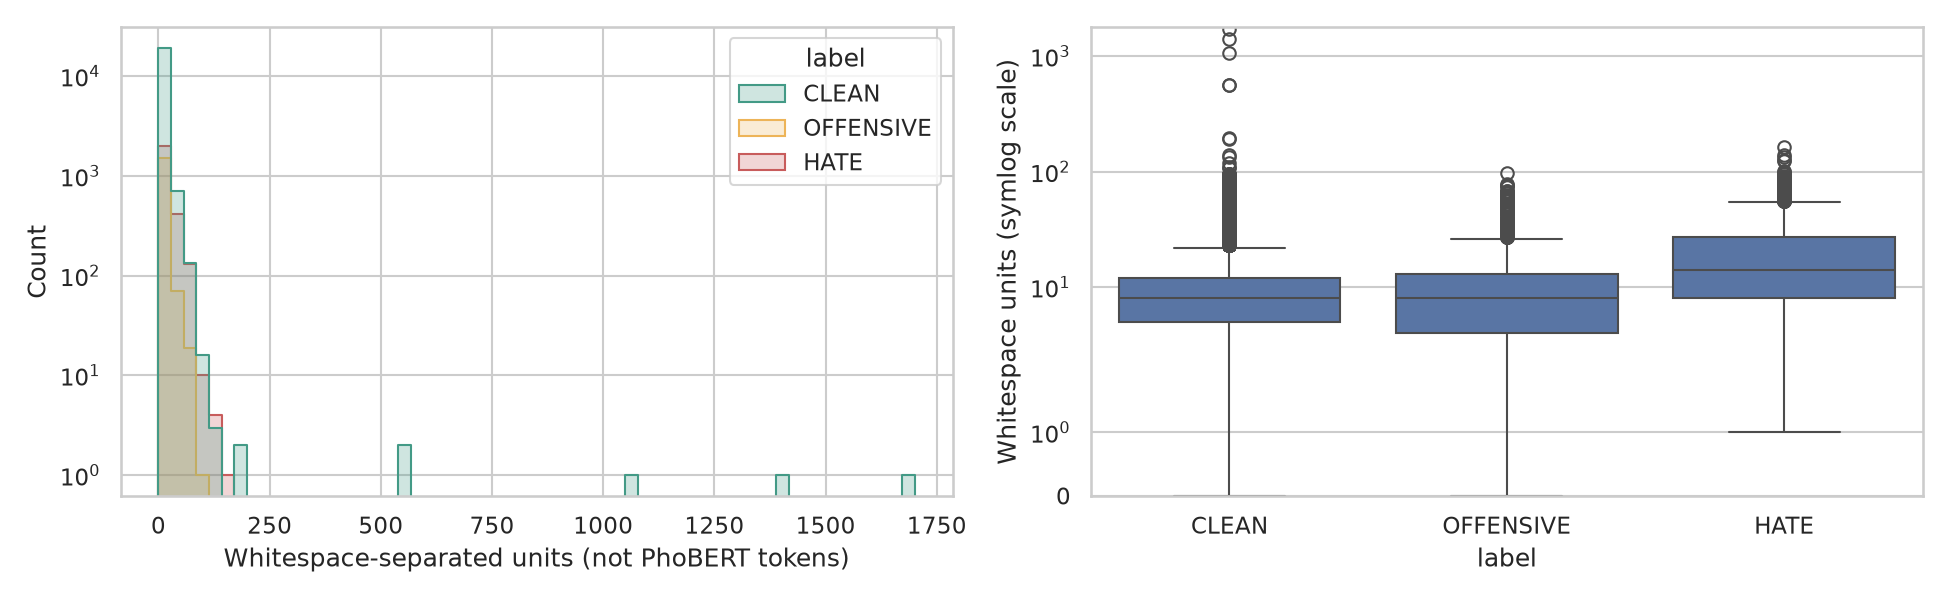

In [3]:
display(train.assign(whitespace_units=train.free_text.str.split().str.len())
        .groupby('label_id').whitespace_units.describe(percentiles=[.5, .9, .95, .99]))
display(Image(filename=str(ROOT / 'reports/stage1/figures/text_lengths.png')))

## 3. Word clouds và top n-grams theo lớp — train only

Chưa tách từ: các term là đơn vị chữ. Không bỏ stopwords để tránh quyết định ngôn ngữ tùy ý; vì vậy từ chức năng có thể đứng đầu. Tần suất cao không đồng nghĩa feature có tính phân biệt hay quan hệ nhân quả.

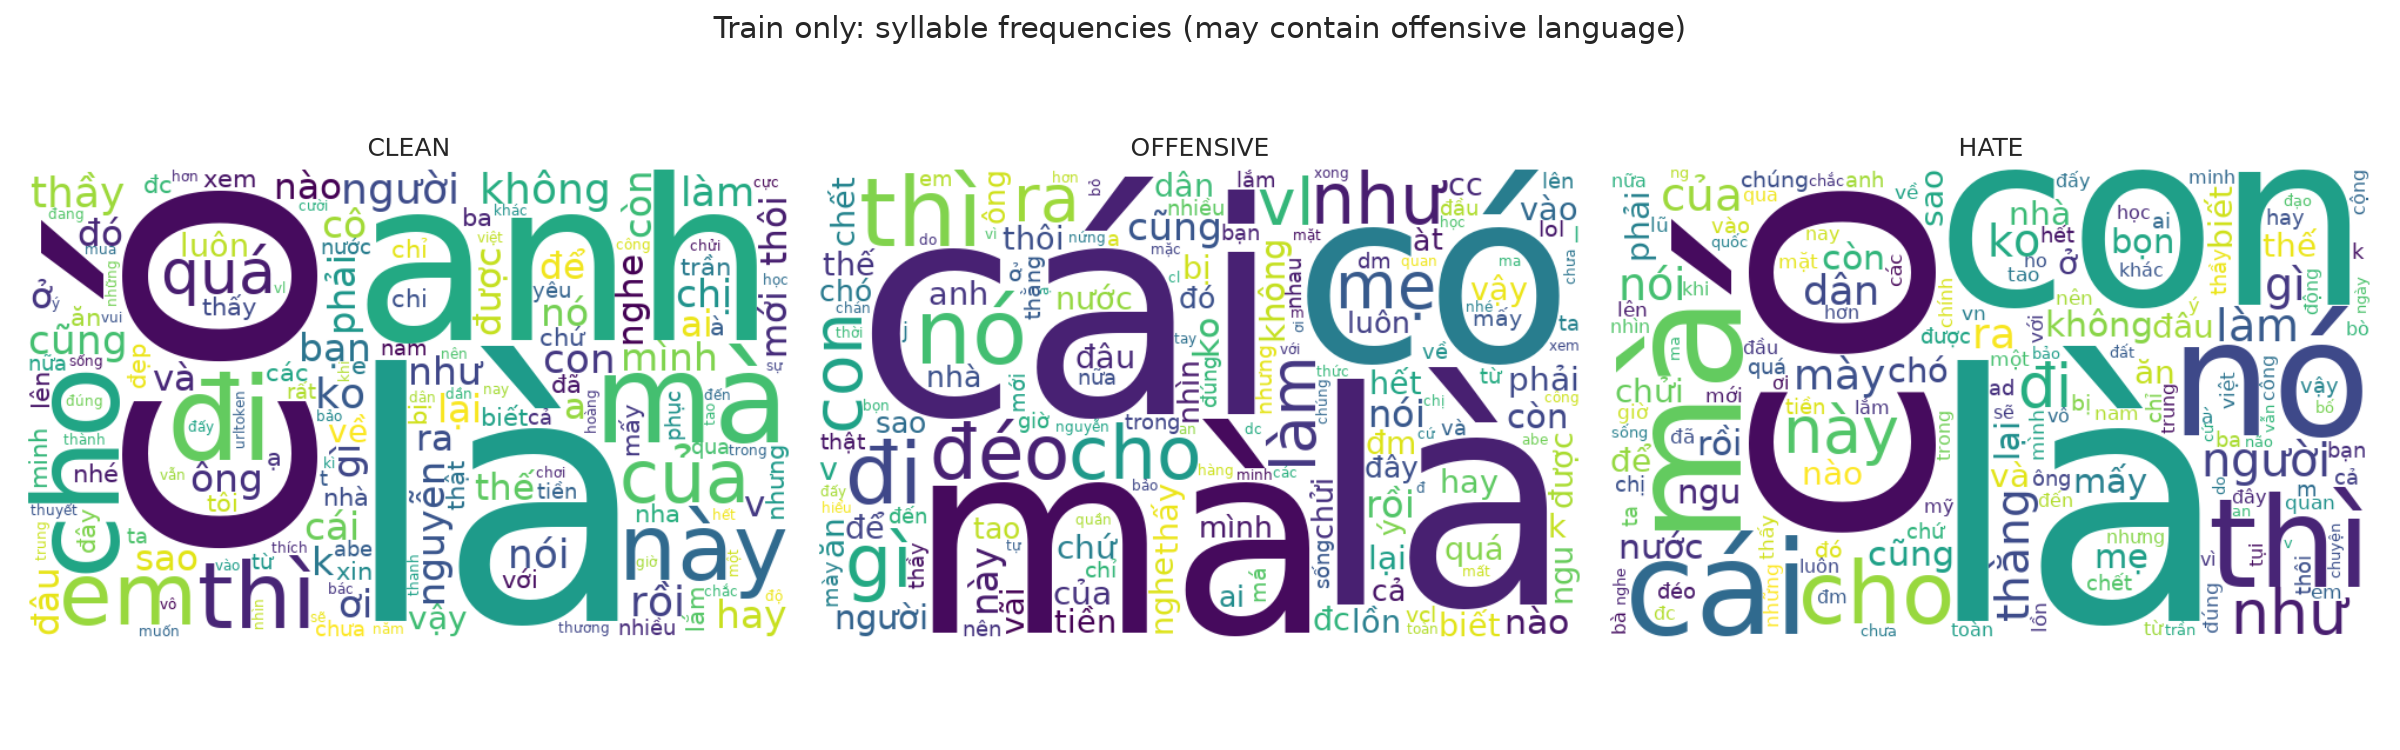

### Top 1-grams

,label,n,term,count
0,CLEAN,1,là,2479
1,CLEAN,1,có,2420
2,CLEAN,1,anh,1737
3,CLEAN,1,mà,1672
4,CLEAN,1,cho,1541
5,CLEAN,1,đi,1493
6,CLEAN,1,này,1425
7,CLEAN,1,thì,1371
8,CLEAN,1,em,1213
9,CLEAN,1,của,1162


### Top 2-grams

,label,n,term,count
0,CLEAN,2,thuyết phục,342
1,CLEAN,2,việt nam,233
2,CLEAN,2,cực kì,231
3,CLEAN,2,kì thuyết,196
4,CLEAN,2,trần dần,188
5,CLEAN,2,acc clone,172
6,CLEAN,2,mọi người,150
7,CLEAN,2,các bạn,147
8,CLEAN,2,dễ thương,145
9,CLEAN,2,minh hiếu,144


### Top 3-grams

,label,n,term,count
0,CLEAN,3,cực kì thuyết,194
1,CLEAN,3,kì thuyết phục,188
2,CLEAN,3,cô minh hiếu,69
3,CLEAN,3,dễ thương quá,64
4,CLEAN,3,cực kỳ thuyết,52
5,CLEAN,3,kỳ thuyết phục,50
6,CLEAN,3,chu cà mo,48
7,CLEAN,3,nhà tiên tri,44
8,CLEAN,3,ông trần dần,43
9,CLEAN,3,sống chậm thôi,43


In [4]:
display(Image(filename=str(ROOT / 'reports/stage1/figures/wordclouds.png')))
grams = pd.read_csv(ROOT / 'reports/stage1/train_ngrams.csv')
for n in (1, 2, 3):
    display(Markdown(f'### Top {n}-grams'))
    display(grams[grams.n.eq(n)].groupby('label', sort=False).head(10).reset_index(drop=True))

## 4. Leakage và xung đột nhãn

Khóa duplicate = preprocessing + casefold + gộp khoảng trắng. Mask URL/mention có thể tạo collision; chưa phát hiện near-duplicate. Bản train bổ sung bỏ overlap với holdout và quarantine nhóm nhãn xung đột, không tự sửa nhãn. Giữ nguyên validation/test, kể cả overlap giữa hai tập này.

In [5]:
display(pd.DataFrame(report['cross_split_overlap']).T.fillna('—'))
display(pd.Series(report['decontaminated_train']))

,unique_normalized_texts,train_rows,validation_rows,conflicting_label_groups,test_rows
train__validation,322.0,357.0,325.0,28.0,—
train__test,792.0,857.0,—,80.0,809.0
validation__test,92.0,—,96.0,13.0,95.0


rows                                                                      21292
excluded_by_primary_reason    {'duplicate_train': 1312, 'holdout_overlap': 1...
dtype: object

## 5. Tiền xử lý và ablation dự kiến

Giữ emoji/emoticon, số, dấu câu và hoa/thường mặc định. Lowercase/teen code chỉ là tùy chọn, cần kiểm chứng bằng validation. Các ví dụ bên dưới là tự tạo, không lấy từ test. `text_clean` cần word segmentation trước khi tokenization PhoBERT.

In [6]:
examples = ['KO dc nói vậy!!! 😡 :)))', 'Xem https://example.org @ban #học_tập', 'Tiếng Việt 123 ❤️']
ablation = PreprocessingConfig(lowercase=True, normalize_teencode=True)
display(pd.DataFrame({'raw': examples,
                      'default': [preprocess_text(t) for t in examples],
                      'lowercase_teencode': [preprocess_text(t, ablation) for t in examples]}))
display(pd.Series(report['preprocessing'], name='Default config'))

,raw,default,lowercase_teencode
0,KO dc nói vậy!!! 😡 :))),KO dc nói vậy!!! 😡 :))),không được nói vậy!!! 😡 :)))
1,Xem https://example.org @ban #học_tập,Xem urltoken usertoken học_tập,xem urltoken usertoken học_tập
2,Tiếng Việt 123 ❤️,Tiếng Việt 123 ❤️,tiếng việt 123 ❤️


lowercase               False
normalize_teencode      False
mask_urls                True
mask_mentions            True
strip_hashtag_marker     True
Name: Default config, dtype: bool

## 6. Imbalanced data

Class weights = N / (3 × số mẫu lớp), tính lại theo đúng bản train dùng để học. Weighted CrossEntropy và WeightedRandomSampler là hai thí nghiệm riêng. Không oversampling holdout; giữ split sẵn có nên không chia stratified lại.

In [7]:
display(pd.DataFrame(report['class_weights']).rename(index=LABELS))
majority_fraction = train.label_id.value_counts(normalize=True).max()
print(f'Accuracy nếu luôn đoán majority trên train: {majority_fraction:.2%}')
print('Đây chỉ là mốc mô tả train, không phải kết quả đánh giá model.')

,official_train,decontaminated_train
CLEAN,0.403098,0.404937
OFFENSIVE,4.991283,5.015783
HATE,3.136150,3.020142


Accuracy nếu luôn đoán majority trên train: 82.69%
Đây chỉ là mốc mô tả train, không phải kết quả đánh giá model.


## 7. Kết luận và bàn giao Stage 2

Dùng Macro-F1 làm chỉ số chính, kèm F1/recall từng lớp. Làm baseline TF-IDF + Logistic Regression trước PhoBERT. So sánh official/decontaminated theo giao thức công bố rõ; cân nhắc tác động collision của preprocessing. Chọn tách từ, đo subword/truncation trên train/validation; không dùng test để tuning. Chưa có kết quả model để đưa lên CV.

In [8]:
display(Markdown((ROOT / 'reports/stage1/summary.md').read_text(encoding='utf-8')))

# Stage 1 — Kết quả trên dữ liệu thực

Tạo lại bằng `python -m src.stage1`.

| Split | Rows | CLEAN | OFFENSIVE | HATE | Empty | Duplicate excess (normalized) |
|---|---:|---:|---:|---:|---:|---:|
| train | 24048 | 19886 | 1606 | 2556 | 2 | 1535 |
| validation | 2672 | 2190 | 212 | 270 | 0 | 22 |
| test | 6680 | 5548 | 444 | 688 | 0 | 107 |

## Trùng lặp giữa các tập

Khóa so sánh: preprocessing mặc định + casefold + chuẩn hóa khoảng trắng. Không phải kiểm tra tương đồng ngữ nghĩa.

- train__validation: 322 nội dung chung; 28 nhóm khác nhãn.
- train__test: 792 nội dung chung; 80 nhóm khác nhãn.
- validation__test: 92 nội dung chung; 13 nhóm khác nhãn.

Train loại overlap / duplicate / conflict / empty: **21292** dòng (gốc 24048).

## Class weights: N / (3 × count)

Theo thứ tự CLEAN, OFFENSIVE, HATE:

- official_train: CLEAN=0.4031, OFFENSIVE=4.9913, HATE=3.1362
- decontaminated_train: CLEAN=0.4049, OFFENSIVE=5.0158, HATE=3.0201

## Diễn giải và giới hạn

- Chỉ dự đoán lớp đông nhất đã đạt accuracy 82.69% trên train; đây không phải kết quả model trên test.
- Ưu tiên Macro-F1, kèm F1/recall từng lớp; Weighted-F1 và accuracy là chỉ số bổ sung.
- EDA nội dung, n-grams, word clouds chỉ dùng train. Audit holdout chỉ phục vụ kiểm tra chất lượng, không chọn hyperparameter.
- N-grams/độ dài tính theo đơn vị chữ phân cách bởi khoảng trắng, chưa phải từ tiếng Việt hoặc subword PhoBERT.
- Bản decontaminated là thí nghiệm bổ sung; phải công bố số dòng và không so trực tiếp như cùng giao thức benchmark.
- Validation/test có overlap vẫn được giữ nguyên; ghi rõ giới hạn này khi báo cáo kết quả cuối.
- Placeholder URL/mention có thể gộp hai nội dung khác nhau; cần review chính sách trước khi chốt giao thức huấn luyện.
- Chưa huấn luyện model, chưa chọn độ dài tokenizer và chưa thực hiện word segmentation.


## 8. Provenance và tái lập

SHA-256 ghi nhận đúng đầu vào của lần chạy, không chứng minh nguồn gốc phát hành. Xem requirements-lock.txt cho toàn bộ phiên bản môi trường.

In [9]:
display(report['provenance'])

{'source': 'https://github.com/sonlam1102/vihsd',
 'note': 'Local CSVs supplied by user; hashes identify files, not verified original release membership.',
 'files': {'train': {'sha256': '516a4ac12bcfd64720a6de352b3c30d019377f90a5907eff80e91d0ae2526360'},
  'validation': {'sha256': '1d42bc7e78b796f9a61bb30490171e5d48cbdee41f97c1235754894d28402ff7'},
  'test': {'sha256': 'ba8ae9b62c40caebcbe8af9a09590296bca286e83e22dd639de31a62ed16f5a5'}},
 'python': '3.14.5',
 'packages': {'pandas': '3.0.6',
  'numpy': '2.5.3',
  'matplotlib': '3.11.2',
  'seaborn': '0.13.2',
  'wordcloud': '1.9.6'},
 'seed': 42}